# BBO-Rietveld Y2O3

In this notebook, you can see how to automate Rietveld refinement with black-box optimization.  
Run the following cells to run the optimization.

## Documentations
- [JupyterLab](https://jupyterlab.readthedocs.io/en/stable/)
- [GSASIIscriptable: Scripting Interface](https://gsas-ii.readthedocs.io/en/latest/GSASIIscriptable.html)
- [Optuna](https://optuna.readthedocs.io/en/stable/)


In [1]:
# import packages
%matplotlib inline

import os
import sys
from multiprocessing import Process, Queue
import pandas as pd
import optuna
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from dataclasses import dataclass
sys.path.append('~/src/GSASII/GSASII/')

In [2]:
# Configurations
RANDOM_SEED = 1024
STUDY_NAME = 'Y2O3'
DATA_DIR = 'data/' + STUDY_NAME
# all output files include GSAS project file (*.gpx) will be saved in WORK_DIR
WORK_DIR = 'work/' + STUDY_NAME

In [3]:
# make directories
! rm -f $WORK_DIR/$STUDY_NAME*
! mkdir -p $WORK_DIR

zsh:1: no matches found: work/Y2O3/Y2O3*


In [4]:
@dataclass
class ProjectConfig:
    work_dir: str
    random_seed: int
    data_dir: str
    cif_file: str
    csv_file: str
    prm_file: str

In [5]:
class Project:
    def __init__(self, config: ProjectConfig, trial_number: int):
        import GSASIIscriptable as G2sc
        self.gpx = G2sc.G2Project(newgpx=os.path.join(
            config.work_dir, f'project_seed{config.random_seed}_trial_{trial_number}.gpx'))

        self.hist1 = self.gpx.add_powder_histogram(
            os.path.join(config.data_dir, config.csv_file), os.path.join(config.data_dir, config.prm_file))
        
        self.phase0 = self.gpx.add_phase(os.path.join(config.data_dir, config.cif_file),
                                         phasename=config.cif_file.split(".cif")[0],
                                         histograms=[self.hist1])
        
        self.hist1.data['Instrument Parameters'][0]['I(L2)/I(L1)'] = [0.5, 0.5, 0]

        # Set to use iso
        for val in self.phase0.data['Atoms']:
            val[9] = 'I'

    def refine_and_calc_Rwp(self, param_dict):
        self.gpx.do_refinements([param_dict])
        for hist in self.gpx.histograms():
            _, Rwp = hist.name, hist.get_wR()
        return Rwp

In [6]:
# Example usage:
config = ProjectConfig(
    work_dir=WORK_DIR,
    random_seed=RANDOM_SEED,
    data_dir=DATA_DIR,
    cif_file='Y2O3.cif',
    csv_file='Y2O3.csv',
    prm_file='INST_XRY.PRM'
)

In the objective function, first, configurations for the following parameters are sampled.
Then, the crystal structure is refined by GSAS-II.
Finally, the calculated Rwp is returned.

| Parameter                                 | Parameter type   | Search space                                                                                                      |
|-------------------------------------------|------------------|-------------------------------------------------------------------------------------------------------------------|
| initial 2theta bound refinement           | categorical      | {True, False}                                                                                                      |
| initial 2theta lower bound (deg.)         | real             | [15, 130]                                                                                                          |
| initial 2theta upper bound (deg.)         | real/conditional | [l + 20, 150] (l is the initial 2theta lower bound)                                                                |
| background function                       | categorical      | {Chebyshev, cosine, Q^2 power series, Q^-2 power series, linear interpolate, inverse interpolate, log interpolate} |
| degree of background function             | initegral        | [1, 15]                                                                                                            |
| instrument zero position refinement       | categorical      | {True, False}                                                                                                      |
| sample shift X refinement                 | categorical      | {True, False}                                                                                                      |
| sample shift Y refinement                 | categorical      | {True, False}                                                                                                      |
| scale factor refinement                   | categorical      | {True, False}                                                                                                      |
| peak shape refinement (Gaussian: U, V, W) | categorical      | {True, False}                                                                                                      |
| peak shape refinement (Lorentzian: X, Y)  | categorical      | {True, False}                                                                                                      |
| peak shape refinement (SH/L)              | categorical      | {True, False}                                                                                                      |

In [7]:
def objective(trial, config):
    """
    objective function for Optuna.
    
    You can apply black-box optimization for other data analysis 
    by modifying this function for that task.
    
    Parameters
    ----------
    trial : optuna.trial object

    Returns
    -------
    Rwp : float
    
    """
    
    ### define search space ###
    # Limits (acute angle)
    limits_lb = trial.suggest_float('Limits lower bound', 15, 130)
    limits_ub = trial.suggest_float('Limits upper bound', limits_lb + 20, 150)
    limits_refine = trial.suggest_categorical('limits refine', [True, False])
    refdict0 = {'set': {'Limits': [limits_lb, limits_ub]}, 'refine': limits_refine}

    # Background
    background_type = trial.suggest_categorical(
        'Background type', ['chebyschev',
                            'cosine',
                            'Q^2 power series',
                            'Q^-2 power series',
                            'lin interpolate',
                            'inv interpolate',
                            'log interpolate'])
    no_coeffs = trial.suggest_int('Number of coefficients', 1, 15)  # [1, 15]
    background_refine = trial.suggest_categorical('Background refine', [True, False])
    refdict0bg_h = {
        'set': {
            'Background': {
                'type': background_type,
                'no. coeffs': no_coeffs,
                'refine': background_refine
            }
        }
    }

    # Instrument parameters
    instrument_parameters1_refine = []
    for p in ['Zero']:
        if trial.suggest_categorical('Instrument_parameters refine %s' % (p), [True, False]):
            instrument_parameters1_refine.append(p)
    refdict1_h = {'set': {'Cell': True, 'Instrument Parameters': instrument_parameters1_refine}}

    sample_parameters1_refine =[]
    for p in ['DisplaceX', 'DisplaceY', 'Scale']:
        if trial.suggest_categorical('Sample_parameters refine %s' % (p), [True, False]):
            sample_parameters1_refine.append(p)
    refdict1_h2 = {"set": {'Sample Parameters':sample_parameters1_refine }}

    instrument_parameters2_refine = []
    for p in ['U', 'V', 'W', 'X', 'Y', 'SH/L']:
        if trial.suggest_categorical('Peakshape_parameters refine %s' % (p), [True, False]):
            instrument_parameters2_refine.append(p)
    refdict2_h = {'set': {'Instrument Parameters': instrument_parameters2_refine}}

    refdict3_h = {'set': {'Atoms': {'all': 'XU'}}}

    # Limits (wide angle)
    refdict_fin_h = {'set': {'Limits': [15, 150]}, 'refine': True}

    # Evaluate
    refine_params_list = [refdict0,
                          refdict0bg_h,
                          refdict1_h,
                          refdict1_h2,
                          refdict2_h,
                          refdict3_h,
                          refdict_fin_h]
    
    def evaluate(config, trial_number, refine_params_list):
        ERROR_PENALTY = 1e9      
        try:
            print(config)
            print(trial_number)
            print(refine_params_list)
            # todo: ここを実装（trial_number）を渡す
            project = Project(config, trial_number)
            for params in refine_params_list:
                Rwp = project.refine_and_calc_Rwp(params)                    
            # validate Uiso >= 0
            phase_Y2O3 = project.gpx.phases()[0]
            u_iso_list = [atom.uiso for atom in phase_Y2O3.atoms()]
            if min(u_iso_list) < 0:
                # Uiso < 0
                Rwp = ERROR_PENALTY
            return Rwp
            
        except Exception as e:
            # Refinement failed
            print(e, file=sys.stderr)
            return ERROR_PENALTY
            
    Rwp = evaluate(config, trial.number, refine_params_list)
    
    return Rwp

In [8]:
# Create Optuna study

study = optuna.create_study(study_name=STUDY_NAME + '_seed%s' % (RANDOM_SEED),
                            storage=f"sqlite:///{config.work_dir}/history_sqlite.db", 
                            load_if_exists=True,
                            sampler=optuna.samplers.TPESampler(n_startup_trials=20, seed=RANDOM_SEED))

[I 2026-06-17 12:30:46,468] A new study created in RDB with name: Y2O3_seed1024


Run 200 refinements to find the best configuration. It may take abount an hour to complete.

In [9]:
# Optimize
study.optimize(func=lambda trial: objective(trial, config), n_trials=100)

ProjectConfig(work_dir='work/Y2O3', random_seed=1024, data_dir='data/Y2O3', cif_file='Y2O3.cif', csv_file='Y2O3.csv', prm_file='INST_XRY.PRM')
0
[{'set': {'Limits': [89.4844915261275, 149.87495211917332]}, 'refine': False}, {'set': {'Background': {'type': 'cosine', 'no. coeffs': 14, 'refine': True}}}, {'set': {'Cell': True, 'Instrument Parameters': ['Zero']}}, {'set': {'Sample Parameters': ['DisplaceX', 'DisplaceY', 'Scale']}}, {'set': {'Instrument Parameters': ['U', 'V', 'SH/L']}}, {'set': {'Atoms': {'all': 'XU'}}}, {'set': {'Limits': [15, 150]}, 'refine': True}]
GSAS-II binaries co-located with GSAS-II: /opt/miniconda3/envs/powder/lib/python3.13/site-packages/GSASII
N.B. Configuration file /Users/tsunetomo/.GSASII/config.ini does not exist
New install: start without a config.py file
0 values read from /Users/tsunetomo/.GSASII/config.ini


/var/folders/pk/84gnsrlx53s8rl3z6_f28gbm0000gn/T/ipykernel_73692/2587062992.py:3: UserWarning: Importing GSASIIscriptable as a top level module is deprecated, please import it as a sub-module of GSASII
  import GSASIIscriptable as G2sc


/Users/tsunetomo/dev/BBO-Rietveld-TOF/data/Y2O3/Y2O3.csv read by Reader comma/tab/semicolon separated
Instrument parameters read: /Users/tsunetomo/dev/BBO-Rietveld-TOF/data/Y2O3/INST_XRY.PRM bank 1
Keyed packet: ['Y1', 'Y3+', '0.', '0.', '0.', '0', '0', '0']
Keyed packet: ['Y2', 'Y3+', '0.', '0.', '0.', '0', '0', '0']
Keyed packet: ['O1', 'O2-', '0.', '0.', '0.', '0', '0', '0']
/Users/tsunetomo/dev/BBO-Rietveld-TOF/data/Y2O3/Y2O3.cif read by Reader CIF
gpx file saved as /Users/tsunetomo/dev/BBO-Rietveld-TOF/work/Y2O3/project_seed1024_trial_0.gpx
gpx file saved as /Users/tsunetomo/dev/BBO-Rietveld-TOF/work/Y2O3/project_seed1024_trial_0.gpx
 Hessian Levenberg-Marquardt SVD refinement on 1 variables:
initial chi^2 2.3251e+06 with 3020 obs.
Cycle 0: 0.17s, Chi**2: 1.353e+06 for 3020 obs., Lambda: 0,  Delta: 0.418, SVD=0
Cycle 1: 0.17s, Chi**2: 1.353e+06 for 3020 obs., Lambda: 0,  Delta: 0, SVD=0
converged
Maximum shift/esd = 46.573 for all cycles
Read from file: /Users/tsunetomo/dev/BBO-Ri

[I 2026-06-17 12:31:00,863] Trial 0 finished with value: 8.296339328039814 and parameters: {'Limits lower bound': 89.4844915261275, 'Limits upper bound': 149.87495211917332, 'limits refine': False, 'Background type': 'cosine', 'Number of coefficients': 14, 'Background refine': True, 'Instrument_parameters refine Zero': True, 'Sample_parameters refine DisplaceX': True, 'Sample_parameters refine DisplaceY': True, 'Sample_parameters refine Scale': True, 'Peakshape_parameters refine U': True, 'Peakshape_parameters refine V': True, 'Peakshape_parameters refine W': False, 'Peakshape_parameters refine X': False, 'Peakshape_parameters refine Y': False, 'Peakshape_parameters refine SH/L': True}. Best is trial 0 with value: 8.296339328039814.


ProjectConfig(work_dir='work/Y2O3', random_seed=1024, data_dir='data/Y2O3', cif_file='Y2O3.cif', csv_file='Y2O3.csv', prm_file='INST_XRY.PRM')
1
[{'set': {'Limits': [63.10178432316372, 134.92658487233535]}, 'refine': True}, {'set': {'Background': {'type': 'lin interpolate', 'no. coeffs': 14, 'refine': False}}}, {'set': {'Cell': True, 'Instrument Parameters': ['Zero']}}, {'set': {'Sample Parameters': ['DisplaceY', 'Scale']}}, {'set': {'Instrument Parameters': ['V', 'Y']}}, {'set': {'Atoms': {'all': 'XU'}}}, {'set': {'Limits': [15, 150]}, 'refine': True}]
/Users/tsunetomo/dev/BBO-Rietveld-TOF/data/Y2O3/Y2O3.csv read by Reader comma/tab/semicolon separated
Instrument parameters read: /Users/tsunetomo/dev/BBO-Rietveld-TOF/data/Y2O3/INST_XRY.PRM bank 1
Keyed packet: ['Y1', 'Y3+', '0.', '0.', '0.', '0', '0', '0']
Keyed packet: ['Y2', 'Y3+', '0.', '0.', '0.', '0', '0', '0']
Keyed packet: ['O1', 'O2-', '0.', '0.', '0.', '0', '0', '0']
/Users/tsunetomo/dev/BBO-Rietveld-TOF/data/Y2O3/Y2O3.cif re

...

Maximum shift/esd = 37.195 for all cycles
Note highly correlated parameters:
 ** :0:Back;4 and :0:Back;6 (@98.35%)
 ** :0:Back;5 and :0:Back;7 (@98.77%)
Read from file: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work/Y2O3/project_seed1024_trial_97.bak0.gpx
Save to file: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work/Y2O3/project_seed1024_trial_97.gpx
GPX file save successful
 Refinement results are in file: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work/Y2O3/project_seed1024_trial_97.lst
 ***** Refinement successful *****
Reported from refinement:
Note highly correlated parameters:
 ** :0:Back;4 and :0:Back;6 (@98.35%)
 ** :0:Back;5 and :0:Back;7 (@98.77%)
ProjectConfig(work_dir='work/Y2O3', random_seed=1024, data_dir='data/Y2O3', cif_file='Y2O3.cif', csv_file='Y2O3.csv', prm_file='INST_XRY.PRM')
98
[{'set': {'Limits': [55.67645272544474, 87.33894153823644]}, 'refine': True}, {'set': {'Background': {'type': 'chebyschev', 'no. coeffs': 9, 'refine': True}}}, {'set': {'Cell': True, 'Instrument Paramet

[I 2026-06-17 12:35:22,730] Trial 98 finished with value: 9.23991100389292 and parameters: {'Limits lower bound': 55.67645272544474, 'Limits upper bound': 87.33894153823644, 'limits refine': True, 'Background type': 'chebyschev', 'Number of coefficients': 9, 'Background refine': True, 'Instrument_parameters refine Zero': False, 'Sample_parameters refine DisplaceX': True, 'Sample_parameters refine DisplaceY': True, 'Sample_parameters refine Scale': True, 'Peakshape_parameters refine U': False, 'Peakshape_parameters refine V': True, 'Peakshape_parameters refine W': True, 'Peakshape_parameters refine X': False, 'Peakshape_parameters refine Y': True, 'Peakshape_parameters refine SH/L': True}. Best is trial 69 with value: 6.835173882880562.


Cycle 2: 0.17s, Chi**2: 59339 for 6751 obs., Lambda: 0,  Delta: 0.00691, SVD=0
Maximum shift/esd = 59.987 for all cycles
Note highly correlated parameters:
 ** :0:Back;4 and :0:Back;6 (@98.29%)
 ** :0:Back;5 and :0:Back;7 (@98.78%)
 ** :0:Back;6 and :0:Back;8 (@99.06%)
Read from file: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work/Y2O3/project_seed1024_trial_98.bak0.gpx
Save to file: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work/Y2O3/project_seed1024_trial_98.gpx
GPX file save successful
 Refinement results are in file: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work/Y2O3/project_seed1024_trial_98.lst
 ***** Refinement successful *****
Reported from refinement:
Note highly correlated parameters:
 ** :0:Back;4 and :0:Back;6 (@98.29%)
 ** :0:Back;5 and :0:Back;7 (@98.78%)
 ** :0:Back;6 and :0:Back;8 (@99.06%)
ProjectConfig(work_dir='work/Y2O3', random_seed=1024, data_dir='data/Y2O3', cif_file='Y2O3.cif', csv_file='Y2O3.csv', prm_file='INST_XRY.PRM')
99
[{'set': {'Limits': [51.89093891625291, 80.9863

[I 2026-06-17 12:35:24,495] Trial 99 finished with value: 6.932130444367086 and parameters: {'Limits lower bound': 51.89093891625291, 'Limits upper bound': 80.98639174678814, 'limits refine': True, 'Background type': 'chebyschev', 'Number of coefficients': 9, 'Background refine': True, 'Instrument_parameters refine Zero': False, 'Sample_parameters refine DisplaceX': False, 'Sample_parameters refine DisplaceY': True, 'Sample_parameters refine Scale': True, 'Peakshape_parameters refine U': False, 'Peakshape_parameters refine V': True, 'Peakshape_parameters refine W': True, 'Peakshape_parameters refine X': True, 'Peakshape_parameters refine Y': True, 'Peakshape_parameters refine SH/L': True}. Best is trial 69 with value: 6.835173882880562.


Cycle 2: 0.17s, Chi**2: 33399 for 6751 obs., Lambda: 0,  Delta: 0.000639, SVD=0
converged
Maximum shift/esd = 36.804 for all cycles
Note highly correlated parameters:
 ** :0:Back;4 and :0:Back;6 (@98.29%)
 ** :0:Back;5 and :0:Back;7 (@98.77%)
 ** :0:Back;6 and :0:Back;8 (@99.07%)
Read from file: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work/Y2O3/project_seed1024_trial_99.bak0.gpx
Save to file: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work/Y2O3/project_seed1024_trial_99.gpx
GPX file save successful
 Refinement results are in file: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work/Y2O3/project_seed1024_trial_99.lst
 ***** Refinement successful *****
Reported from refinement:
Note highly correlated parameters:
 ** :0:Back;4 and :0:Back;6 (@98.29%)
 ** :0:Back;5 and :0:Back;7 (@98.77%)
 ** :0:Back;6 and :0:Back;8 (@99.07%)


In [15]:
# Results
df = study.trials_dataframe()
df.columns = [''.join(col).replace('params', '').strip() for col in df.columns.values]
df.rename(columns={'value':'Rwp', 'number':'trial'}, inplace=True)
df.sort_values('Rwp')

,trial,Rwp,datetime_start,datetime_complete,duration,_Background refine,_Background type,_Instrument_parameters refine Zero,_Limits lower bound,_Limits upper bound,...,_Peakshape_parameters refine U,_Peakshape_parameters refine V,_Peakshape_parameters refine W,_Peakshape_parameters refine X,_Peakshape_parameters refine Y,_Sample_parameters refine DisplaceX,_Sample_parameters refine DisplaceY,_Sample_parameters refine Scale,_limits refine,state
69,69,6.835174e+00,2026-06-17 12:34:19.617887,2026-06-17 12:34:22.028183,0 days 00:00:02.410296,True,chebyschev,False,37.584176,97.972763,...,False,True,True,True,True,True,True,True,True,COMPLETE
99,99,6.932130e+00,2026-06-17 12:35:22.733637,2026-06-17 12:35:24.493673,0 days 00:00:01.760036,True,chebyschev,False,51.890939,80.986392,...,False,True,True,True,True,False,True,True,True,COMPLETE
72,72,7.026193e+00,2026-06-17 12:34:26.258865,2026-06-17 12:34:28.423418,0 days 00:00:02.164553,True,chebyschev,False,39.789646,91.680827,...,False,True,True,True,True,True,True,True,True,COMPLETE
94,94,7.026287e+00,2026-06-17 12:35:10.991549,2026-06-17 12:35:12.713863,0 days 00:00:01.722314,True,chebyschev,False,54.400486,80.667603,...,False,True,True,True,True,True,True,True,True,COMPLETE
93,93,7.026395e+00,2026-06-17 12:35:09.316915,2026-06-17 12:35:10.986374,0 days 00:00:01.669459,True,chebyschev,False,56.518418,80.501211,...,False,True,True,True,True,True,True,True,True,COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,64,1.000000e+09,2026-06-17 12:34:09.162536,2026-06-17 12:34:11.029051,0 days 00:00:01.866515,True,Q^-2 power series,True,43.644749,85.940776,...,False,False,True,True,True,True,True,True,True,COMPLETE
53,53,1.000000e+09,2026-06-17 12:33:39.153997,2026-06-17 12:33:42.016427,0 days 00:00:02.862430,True,Q^-2 power series,True,65.128666,112.565019,...,False,False,True,True,True,True,True,False,False,COMPLETE
60,60,1.000000e+09,2026-06-17 12:33:59.926674,2026-06-17 12:34:02.046145,0 days 00:00:02.119471,False,Q^2 power series,False,64.160646,94.976571,...,False,True,True,False,False,True,True,True,True,COMPLETE
9,9,1.000000e+09,2026-06-17 12:31:33.262125,2026-06-17 12:31:36.868092,0 days 00:00:03.605967,False,Q^-2 power series,False,103.133489,126.844679,...,False,False,False,False,True,False,False,False,True,COMPLETE


In [16]:
# Best configuration
study.best_params

{'Limits lower bound': 37.58417569094574,
 'Limits upper bound': 97.97276252710145,
 'limits refine': True,
 'Background type': 'chebyschev',
 'Number of coefficients': 11,
 'Background refine': True,
 'Instrument_parameters refine Zero': False,
 'Sample_parameters refine DisplaceX': True,
 'Sample_parameters refine DisplaceY': True,
 'Sample_parameters refine Scale': True,
 'Peakshape_parameters refine U': False,
 'Peakshape_parameters refine V': True,
 'Peakshape_parameters refine W': True,
 'Peakshape_parameters refine X': True,
 'Peakshape_parameters refine Y': True,
 'Peakshape_parameters refine SH/L': True}

In [17]:
# Best Rwp
study.best_value

6.835173882880562

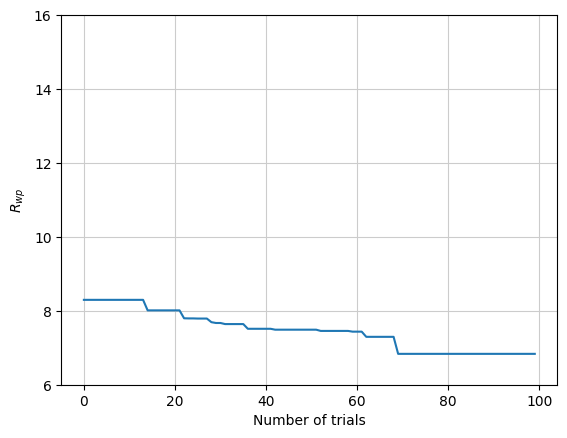

In [18]:
# Rwp plot
def rwp_plot():
    minvalues = [df.iloc[0]['Rwp']]
    for i in range(1, df.shape[0]):
        minvalues.append(min(minvalues[-1], df.iloc[i]['Rwp']))
    minvalues = pd.DataFrame(minvalues)
    
    minvalues.plot(legend=None)
    plt.ylim([6, 16])
    plt.grid(color='#cccccc')
    plt.ylabel('$R_{wp}$')
    plt.xlabel('Number of trials')
    plt.show()
    
rwp_plot()

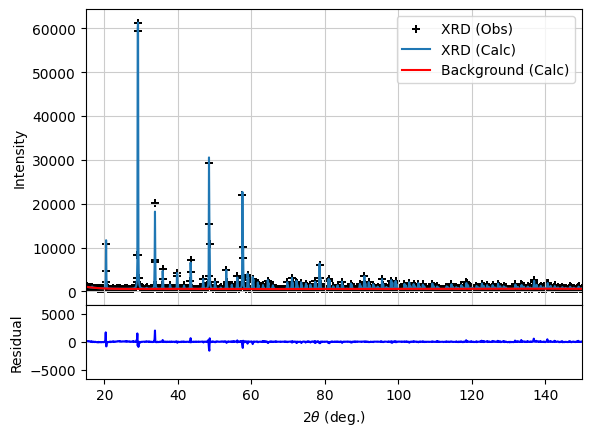

In [19]:
# Rietveld plot
def rietveld_plot():
    import GSASIIscriptable as G2sc

    gpx = G2sc.G2Project(
        f'{WORK_DIR}/project_seed{RANDOM_SEED}_trial_{study.best_trial.number}.gpx')

    hist1 = gpx.histograms()[0]
    phase0 = gpx.phases()[0]

    hist = hist1
    i = 5
    two_theta = hist.getdata("X")[::i]
    Yobs = hist.getdata("Yobs")[::i]
    Ycalc = hist.getdata("Ycalc")[::i]
    bg = hist.getdata("Background")[::i]
    residual = hist.getdata("Residual")[::i]

    fig = plt.figure()
    gs = GridSpec(5, 1, figure=fig)
    ax1 = fig.add_subplot(gs[:4, :])
    ax2 = fig.add_subplot(gs[4, :])
    fig.subplots_adjust(hspace=0)
    ax1.grid(color='#cccccc')

    ax1.scatter(two_theta, Yobs, marker='P', lw=0.0001, c='Black', label='XRD (Obs)')
    ax1.plot(two_theta, Ycalc, label='XRD (Calc)')
    ax1.plot(two_theta, bg, color='red', label='Background (Calc)')
    ax1.set_ylabel('Intensity')
    ax1.legend()
    ax2.plot(two_theta, residual, color='blue')
    plt.setp(ax1.get_xticklabels(), visible=False);
    ax2.set_ylim(-6600, 6600)
    plt.xlabel(r'$2\theta$ (deg.)')
    ax2.set_ylabel('Residual')
    ax1.set_xlim(15, 150)
    ax2.set_xlim(15, 150)
    plt.show()
    
rietveld_plot()